##Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Read files

In [2]:
df = pd.read_csv(r"M:\Data Science 13k\Netflix_Workshop\NetFlix.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...


In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [4]:
df.drop(['show_id', 'title', 'director', 'cast','description'],axis=1,inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          7787 non-null   object
 1   country       7280 non-null   object
 2   date_added    7777 non-null   object
 3   release_year  7787 non-null   int64 
 4   rating        7780 non-null   object
 5   duration      7787 non-null   int64 
 6   genres        7787 non-null   object
dtypes: int64(2), object(5)
memory usage: 426.0+ KB


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7726 entries, 0 to 7786
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          7726 non-null   object
 1   country       7234 non-null   object
 2   date_added    7716 non-null   object
 3   release_year  7726 non-null   int64 
 4   rating        7719 non-null   object
 5   duration      7726 non-null   int64 
 6   genres        7726 non-null   object
dtypes: int64(2), object(5)
memory usage: 482.9+ KB


In [8]:
df.describe()

,release_year,duration
count,7726.000000,7726.000000
mean,2013.920010,69.422728
std,8.788051,50.907957
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [9]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['date_added'] 

C:\Users\taha-\AppData\Local\Temp\ipykernel_27212\334725307.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'])


0      2020-08-14
1      2017-12-15
2      2019-01-05
3      2016-03-01
4      2018-12-03
          ...    
7782   2019-07-12
7783   2020-09-01
7784   2016-08-26
7785   2019-03-08
7786   2016-12-06
Name: date_added, Length: 7726, dtype: datetime64[ns]

In [10]:
df['type'].value_counts()

type
Movie      5348
TV Show    2378
Name: count, dtype: int64

In [11]:
df['type'] = df['type'].map({'TV Show':0,'Movie':1})

In [12]:
df['type'].value_counts()

type
1    5348
0    2378
Name: count, dtype: int64

In [13]:
df['country'].value_counts()

country
United States                                                                      2541
India                                                                               920
United Kingdom                                                                      391
Japan                                                                               226
Canada                                                                              177
                                                                                   ... 
United States, Brazil, India, Uganda, China                                           1
France, Brazil, Spain, Belgium                                                        1
Saudi Arabia, Netherlands, Germany, Jordan, United Arab Emirates, United States       1
United Kingdom,                                                                       1
France, Luxembourg, United States                                                     1
Name: count, Length: 681

conver "country" to int type

In [14]:

# Missing values
df["country"] = df["country"].fillna("Unknown")

# أول دولة
df["country_first"] = df["country"].str.split(",").str[0].str.strip()

# عدد الدول
df["n_countries"] = df["country"].apply(
    lambda x: 0 if x == "Unknown" else len([c for c in x.split(",") if c.strip()])
)


In [15]:
# بعد كده لا تستخدم country الأصلي في الموديل
df = df.drop(columns=["country"])

In [16]:
df['rating'].value_counts()

rating
TV-MA       2853
TV-14       1911
TV-PG        787
R            665
PG-13        385
TV-Y         274
TV-Y7        267
PG           247
TV-G         193
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

Rating

In [17]:
df = pd.get_dummies(df, columns=["rating"], dtype=int)

In [18]:
df['genres'].value_counts()

genres
Documentaries                                                                      325
Dramas, International Movies                                                       320
Stand-Up Comedy                                                                    319
Comedies, Dramas, International Movies                                             242
Dramas, Independent Movies, International Movies                                   215
                                                                                  ... 
Kids' TV, Reality TV, Science & Nature TV                                            1
International TV Shows, Spanish-Language TV Shows, Stand-Up Comedy & Talk Shows      1
Sci-Fi & Fantasy                                                                     1
International TV Shows, TV Action & Adventure, TV Horror                             1
Stand-Up Comedy & Talk Shows, TV Mysteries, TV Sci-Fi & Fantasy                      1
Name: count, Length: 492, dtype: int

In [19]:
genres = df["genres"].str.get_dummies(sep=", ")
df = pd.concat([df, genres], axis=1)

In [20]:
df.describe()

,type,date_added,release_year,duration,n_countries,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
count,7726.000000,7716,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,...,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000
mean,0.692208,2019-01-05 02:55:59.253499136,2013.920010,69.422728,1.166969,0.005048,0.000388,0.010872,0.031970,0.049832,...,0.019415,0.066917,0.089956,0.008931,0.011649,0.009837,0.001553,0.006472,0.007766,0.063293
min,0.000000,2008-01-01 00:00:00,1925.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2018-02-01 00:00:00,2013.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2019-03-08 12:00:00,2017.000000,88.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,2020-01-23 00:00:00,2018.000000,106.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2021-01-16 00:00:00,2021.000000,312.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,0.461610,NaN,8.788051,50.907957,0.733181,0.070874,0.019703,0.103709,0.175932,0.217611,...,0.137987,0.249894,0.286137,0.094086,0.107307,0.098699,0.039383,0.080191,0.087788,0.243505


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7726 entries, 0 to 7786
Data columns (total 63 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   type                          7726 non-null   int64         
 1   date_added                    7716 non-null   datetime64[ns]
 2   release_year                  7726 non-null   int64         
 3   duration                      7726 non-null   int64         
 4   genres                        7726 non-null   object        
 5   country_first                 7726 non-null   object        
 6   n_countries                   7726 non-null   int64         
 7   rating_G                      7726 non-null   int64         
 8   rating_NC-17                  7726 non-null   int64         
 9   rating_NR                     7726 non-null   int64         
 10  rating_PG                     7726 non-null   int64         
 11  rating_PG-13                  7726 

In [22]:
df.select_dtypes(include="object").columns

Index(['genres', 'country_first'], dtype='object')

In [23]:
df.drop("genres", axis=1, inplace=True)

In [24]:

categorical_features = [
    "country_first"
]

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)



In [25]:
df.drop("country_first", axis=1, inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7726 entries, 0 to 7786
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   type                          7726 non-null   int64         
 1   date_added                    7716 non-null   datetime64[ns]
 2   release_year                  7726 non-null   int64         
 3   duration                      7726 non-null   int64         
 4   n_countries                   7726 non-null   int64         
 5   rating_G                      7726 non-null   int64         
 6   rating_NC-17                  7726 non-null   int64         
 7   rating_NR                     7726 non-null   int64         
 8   rating_PG                     7726 non-null   int64         
 9   rating_PG-13                  7726 non-null   int64         
 10  rating_R                      7726 non-null   int64         
 11  rating_TV-14                  7726 

In [27]:
df.isnull().sum()

type                    0
date_added             10
release_year            0
duration                0
n_countries             0
                       ..
TV Sci-Fi & Fantasy     0
TV Shows                0
TV Thrillers            0
Teen TV Shows           0
Thrillers               0
Length: 61, dtype: int64

In [28]:
df.drop(columns=["date_added"], inplace=True)

#OUTLIERS

In [29]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} Outliers")

release_year: 745 Outliers
duration: 1 Outliers
n_countries: 1641 Outliers
rating_G: 39 Outliers
rating_NC-17: 3 Outliers
rating_NR: 84 Outliers
rating_PG: 247 Outliers
rating_PG-13: 385 Outliers
rating_R: 665 Outliers
rating_TV-14: 1911 Outliers
rating_TV-G: 193 Outliers
rating_TV-PG: 787 Outliers
rating_TV-Y: 274 Outliers
rating_TV-Y7: 267 Outliers
rating_TV-Y7-FV: 6 Outliers
rating_UR: 5 Outliers
Action & Adventure: 719 Outliers
Anime Features: 57 Outliers
Anime Series: 148 Outliers
British TV Shows: 228 Outliers
Children & Family Movies: 524 Outliers
Classic & Cult TV: 27 Outliers
Classic Movies: 103 Outliers
Comedies: 1468 Outliers
Crime TV Shows: 427 Outliers
Cult Movies: 59 Outliers
Documentaries: 775 Outliers
Docuseries: 349 Outliers
Faith & Spirituality: 57 Outliers
Horror Movies: 311 Outliers
Independent Movies: 673 Outliers
International TV Shows: 1174 Outliers
Kids' TV: 412 Outliers
Korean TV Shows: 139 Outliers
LGBTQ Movies: 90 Outliers
Movies: 54 Outliers
Music & Musicals

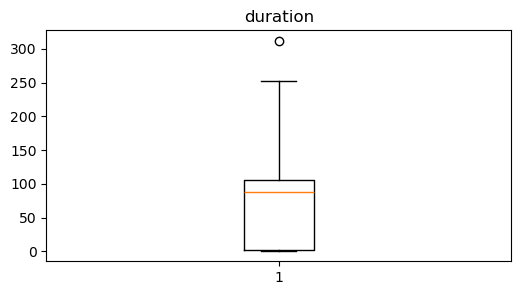

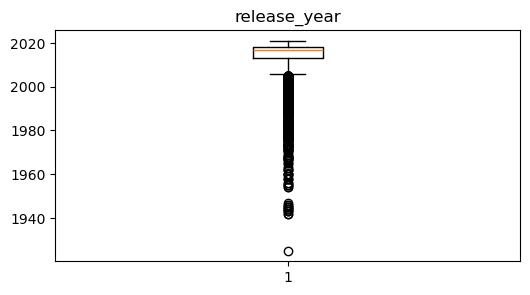

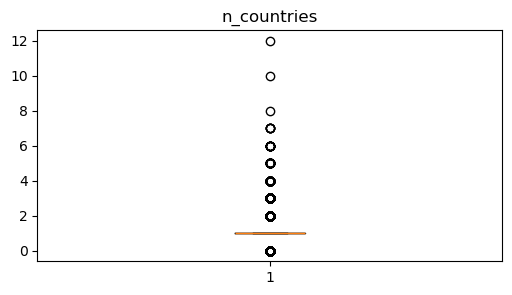

In [30]:
import matplotlib.pyplot as plt

for col in ["duration", "release_year", "n_countries"]:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [31]:
df.describe()

,type,release_year,duration,n_countries,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
count,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,...,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000,7726.000000
mean,0.692208,2013.920010,69.422728,1.166969,0.005048,0.000388,0.010872,0.031970,0.049832,0.086073,...,0.019415,0.066917,0.089956,0.008931,0.011649,0.009837,0.001553,0.006472,0.007766,0.063293
std,0.461610,8.788051,50.907957,0.733181,0.070874,0.019703,0.103709,0.175932,0.217611,0.280490,...,0.137987,0.249894,0.286137,0.094086,0.107307,0.098699,0.039383,0.080191,0.087788,0.243505
min,0.000000,1925.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2013.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2017.000000,88.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,2018.000000,106.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2021.000000,312.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
for col in ["release_year", "duration", "n_countries"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print(f"Lower Bound = {lower}")
    print(f"Upper Bound = {upper}")

    print("Outliers =",
          ((df[col] < lower) | (df[col] > upper)).sum())


release_year
Lower Bound = 2005.5
Upper Bound = 2025.5
Outliers = 745

duration
Lower Bound = -154.0
Upper Bound = 262.0
Outliers = 1

n_countries
Lower Bound = 1.0
Upper Bound = 1.0
Outliers = 1641


In [33]:
df[df["duration"] > 262]

,type,release_year,duration,n_countries,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
7741,1,2018,312,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df["n_countries"].value_counts().sort_index()

n_countries
0      492
1     6085
2      759
3      240
4       96
5       32
6       14
7        5
8        1
10       1
12       1
Name: count, dtype: int64

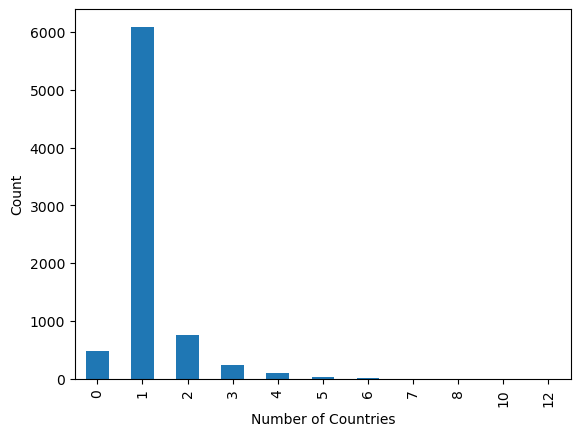

In [35]:
df["n_countries"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of Countries")
plt.ylabel("Count")
plt.show()

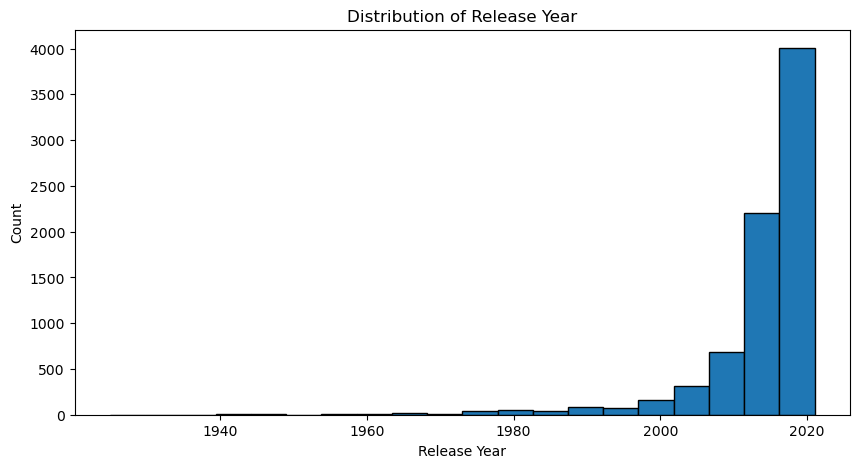

In [36]:
plt.figure(figsize=(10,5))
plt.hist(df["release_year"], bins=20, edgecolor="black")

plt.title("Distribution of Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

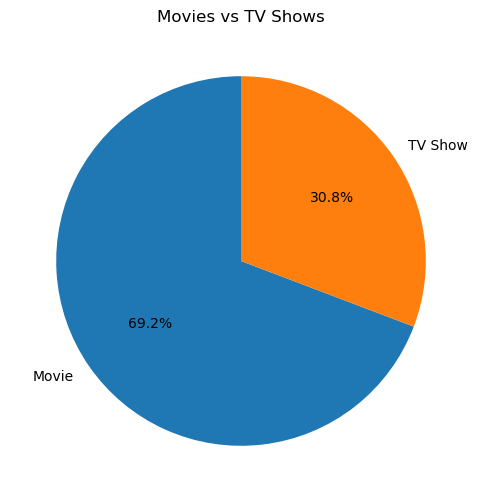

In [37]:
import matplotlib.pyplot as plt

type_counts = df["type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts,
        labels=["Movie","TV Show"],
        autopct="%1.1f%%",
        startangle=90)

plt.title("Movies vs TV Shows")
plt.show()

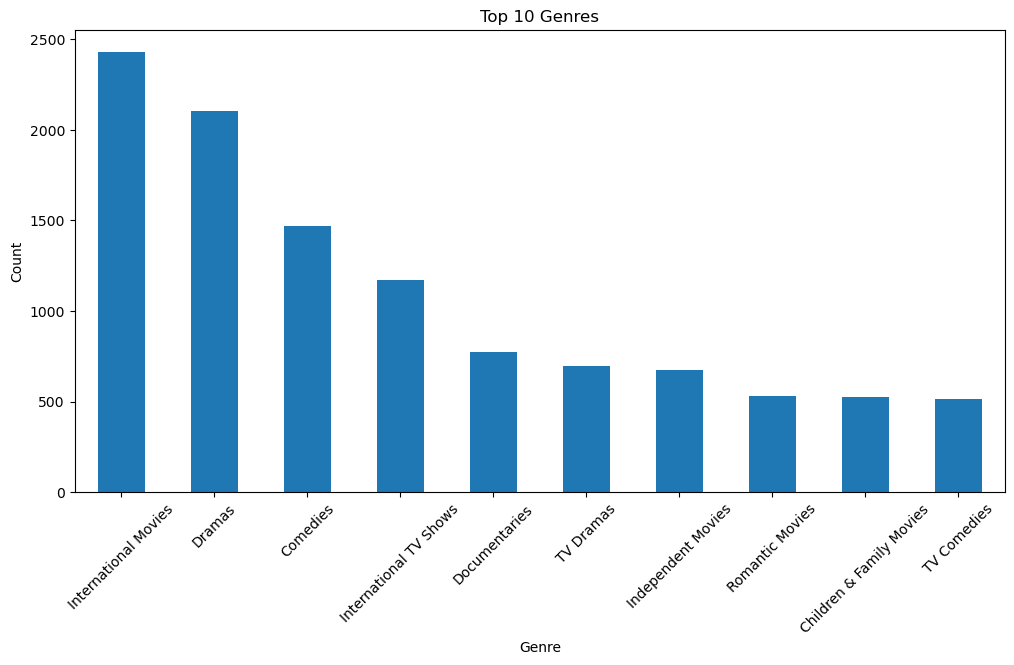

In [38]:
genre_cols = df.columns[19:]   # أو حدد أسماء أعمدة الـ genres

top_genres = df[genre_cols].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_genres.plot(kind="bar")

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

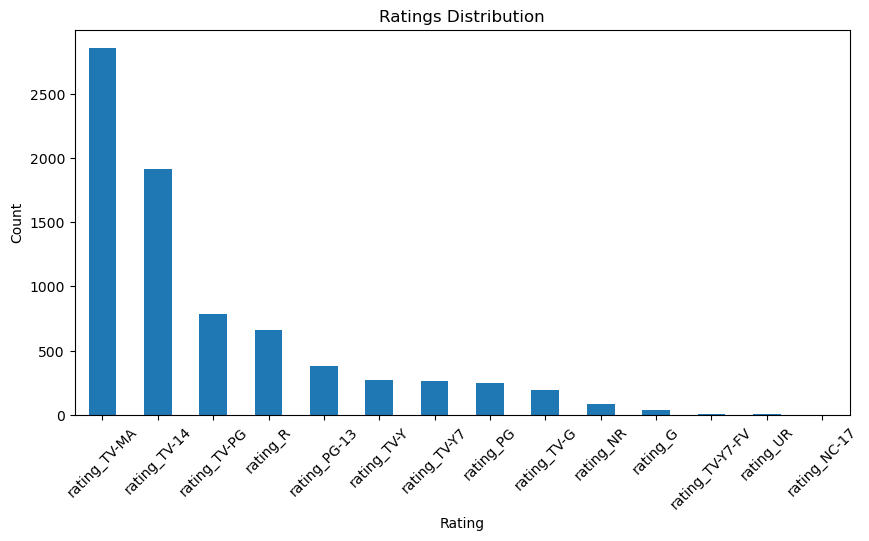

In [39]:
rating_cols = [col for col in df.columns if col.startswith("rating_")]

ratings = df[rating_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ratings.plot(kind="bar")

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

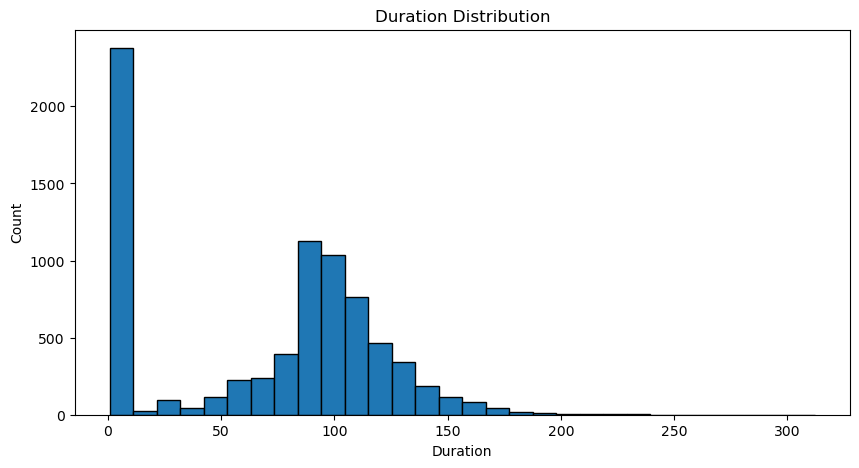

In [40]:
plt.figure(figsize=(10,5))

plt.hist(df["duration"],
         bins=30,
         edgecolor="black")

plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")

plt.show()

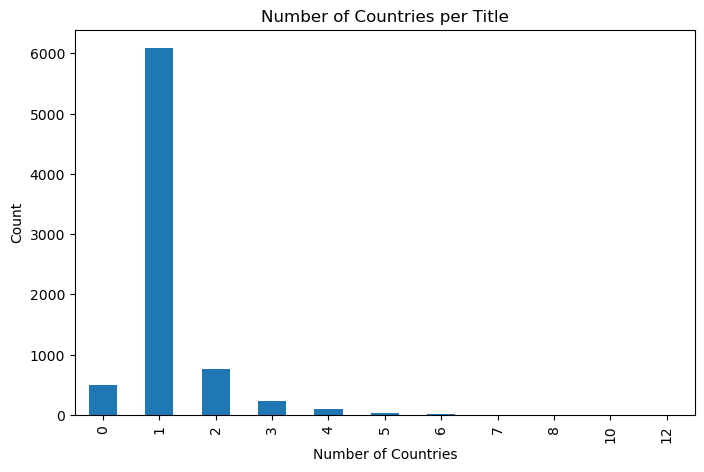

In [41]:
country_counts = df["n_countries"].value_counts().sort_index()

plt.figure(figsize=(8,5))

country_counts.plot(kind="bar")

plt.title("Number of Countries per Title")
plt.xlabel("Number of Countries")
plt.ylabel("Count")

plt.show()

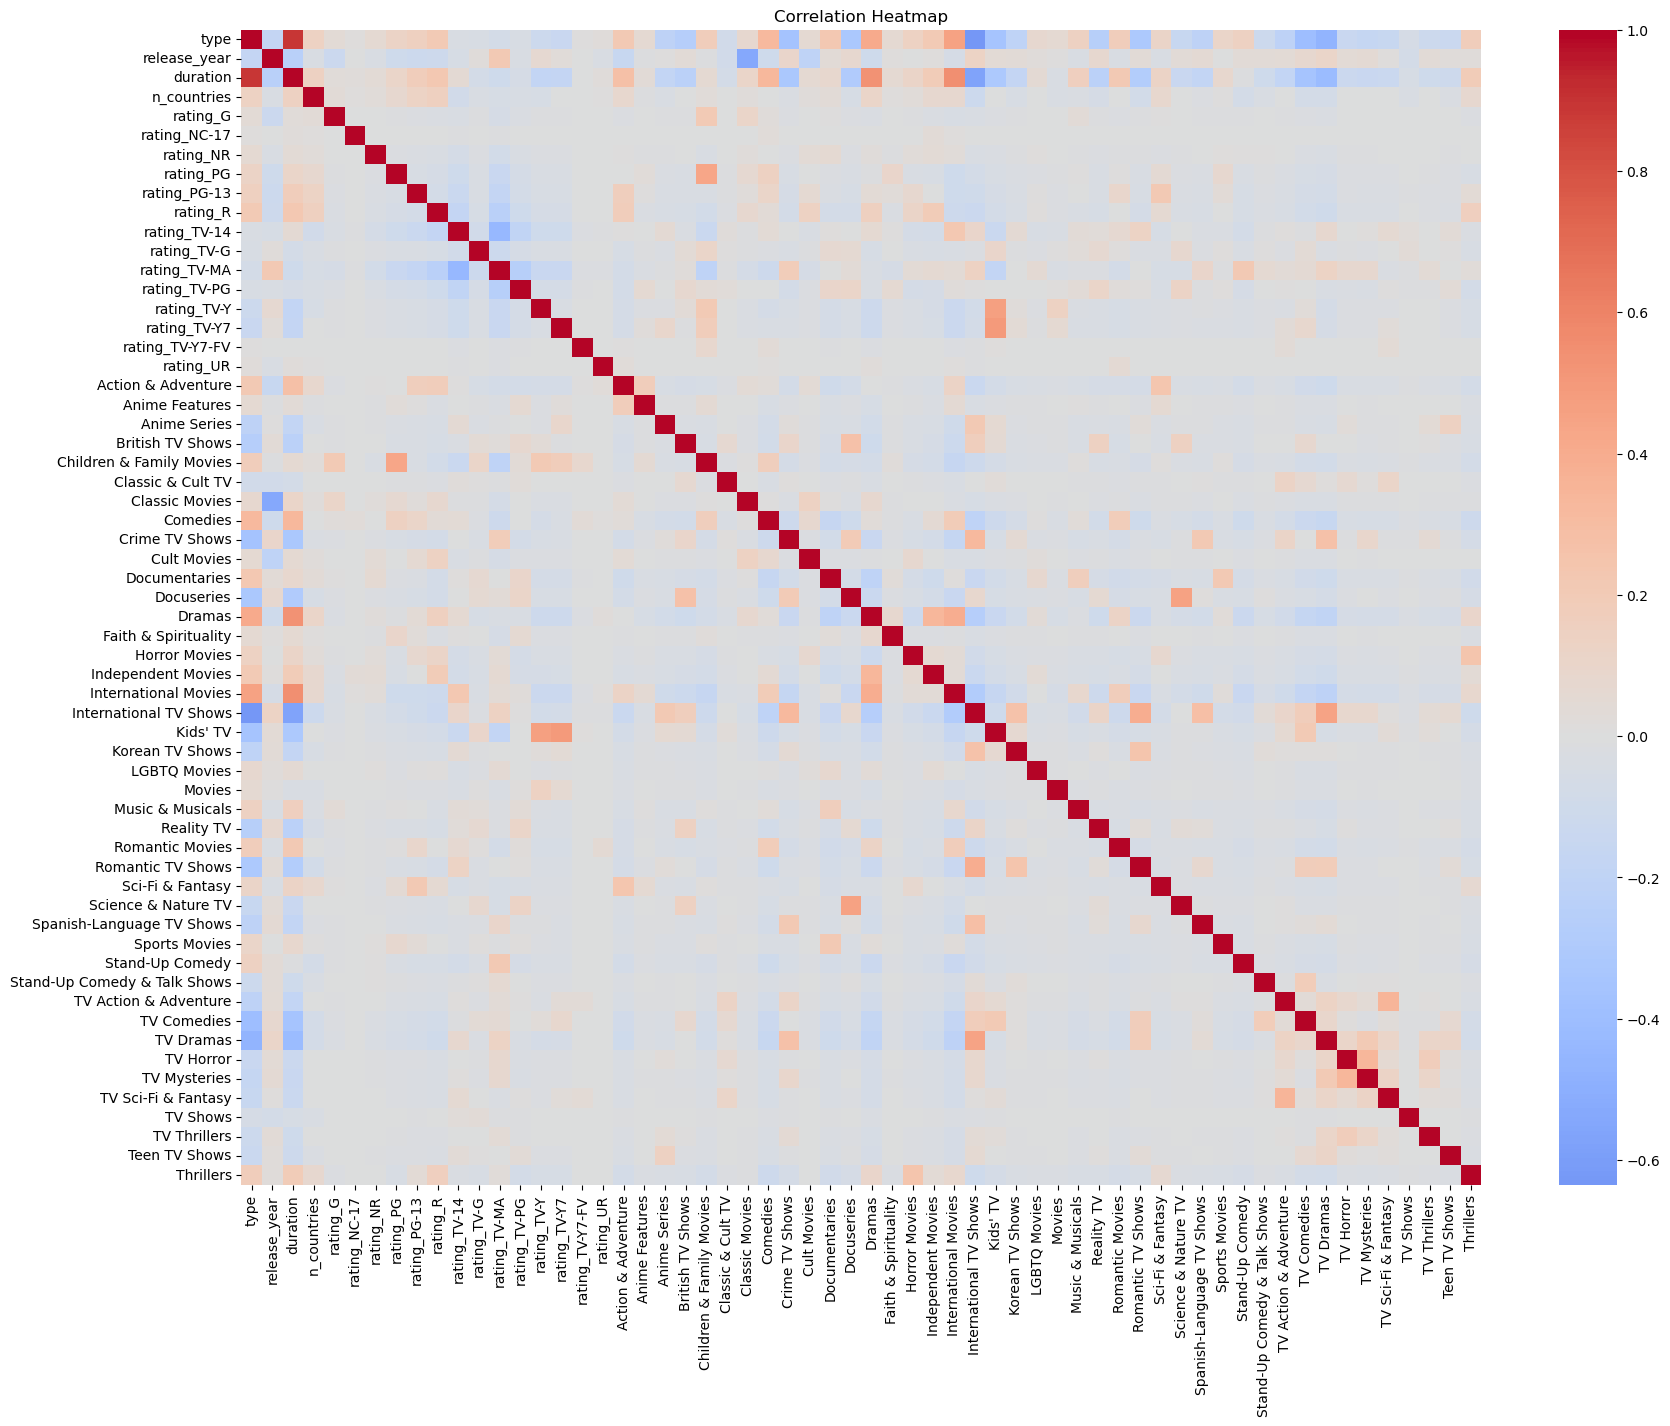

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [43]:
df['duration'].value_counts().sort_index()

duration
1      1577
2       381
3       185
4        87
5        59
       ... 
230       1
233       1
237       1
253       1
312       1
Name: count, Length: 206, dtype: int64

In [44]:
df.columns

Index(['type', 'release_year', 'duration', 'n_countries', 'rating_G',
       'rating_NC-17', 'rating_NR', 'rating_PG', 'rating_PG-13', 'rating_R',
       'rating_TV-14', 'rating_TV-G', 'rating_TV-MA', 'rating_TV-PG',
       'rating_TV-Y', 'rating_TV-Y7', 'rating_TV-Y7-FV', 'rating_UR',
       'Action & Adventure', 'Anime Features', 'Anime Series',
       'British TV Shows', 'Children & Family Movies', 'Classic & Cult TV',
       'Classic Movies', 'Comedies', 'Crime TV Shows', 'Cult Movies',
       'Documentaries', 'Docuseries', 'Dramas', 'Faith & Spirituality',
       'Horror Movies', 'Independent Movies', 'International Movies',
       'International TV Shows', 'Kids' TV', 'Korean TV Shows', 'LGBTQ Movies',
       'Movies', 'Music & Musicals', 'Reality TV', 'Romantic Movies',
       'Romantic TV Shows', 'Sci-Fi & Fantasy', 'Science & Nature TV',
       'Spanish-Language TV Shows', 'Sports Movies', 'Stand-Up Comedy',
       'Stand-Up Comedy & Talk Shows', 'TV Action & Adventure', 'TV C

In [45]:
df[["Movies", "TV Shows"]]

,Movies,TV Shows
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
7782,0,0
7783,0,0
7784,0,0
7785,0,0


ML

In [46]:
X = df.drop(columns=["type", "Movies", "TV Shows"])
y = df["type"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9987063389391979
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       476
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      1546
   macro avg       1.00      1.00      1.00      1546
weighted avg       1.00      1.00      1.00      1546



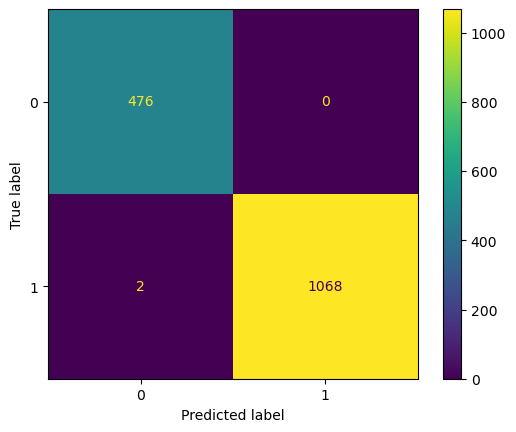

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.show()

تعلم الأله بدون كل الأعمده دي 

In [51]:
tv_movie_features = [
    "Movies",
    "TV Shows",
    "TV Action & Adventure",
    "TV Comedies",
    "TV Dramas",
    "TV Horror",
    "TV Mysteries",
    "TV Sci-Fi & Fantasy",
    "TV Thrillers",
    "Teen TV Shows",
    "British TV Shows",
    "International TV Shows",
    "Crime TV Shows",
    "Kids' TV",
    "Romantic TV Shows",
    "Science & Nature TV",
    "Spanish-Language TV Shows",
    "Korean TV Shows",
    "Reality TV",
    "Docuseries",
    "Anime Series",
    "Classic & Cult TV",
    "Stand-Up Comedy & Talk Shows"
]

In [52]:
X2 = df.drop(columns=["type"] + tv_movie_features)

In [53]:
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model2 = RandomForestClassifier(random_state=42)

model2.fit(X2_train, y_train)

pred2 = model2.predict(X2_test)

print("Accuracy:", accuracy_score(y_test, pred2))
print(classification_report(y_test, pred2))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       476
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      1546
   macro avg       1.00      1.00      1.00      1546
weighted avg       1.00      1.00      1.00      1546



In [54]:
feature_importance = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": model2.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

                     Feature  Importance
1                   duration    0.664773
28      International Movies    0.081261
24                    Dramas    0.056798
21                  Comedies    0.040862
23             Documentaries    0.030771
19  Children & Family Movies    0.020455
34           Stand-Up Comedy    0.019763
17        Action & Adventure    0.015318
8                   rating_R    0.014200
27        Independent Movies    0.009470
35                 Thrillers    0.009290
7               rating_PG-13    0.007309
26             Horror Movies    0.005833
0               release_year    0.005636
31           Romantic Movies    0.005173
30          Music & Musicals    0.003614
32          Sci-Fi & Fantasy    0.002603
14              rating_TV-Y7    0.001714
6                  rating_PG    0.001148
2                n_countries    0.000851


In [55]:
df.groupby("type")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
0,2378.0,1.785955,1.604586,1.0,1.0,1.0,2.0,16.0
1,5348.0,99.497569,28.352245,3.0,86.0,98.0,114.0,312.0


In [56]:
print(df[df["type"] == 0]["duration"].describe())
print("-"*50)
print(df[df["type"] == 1]["duration"].describe())

count    2378.000000
mean        1.785955
std         1.604586
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: duration, dtype: float64
--------------------------------------------------
count    5348.000000
mean       99.497569
std        28.352245
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64


In [57]:
X3 = df.drop(columns=["type"] + tv_movie_features + ["duration"])

In [58]:
X3_train, X3_test, y_train, y_test = train_test_split(
    X3, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model3 = RandomForestClassifier(random_state=42)

model3.fit(X3_train, y_train)

pred3 = model3.predict(X3_test)

print("Accuracy:", accuracy_score(y_test, pred3))
print(classification_report(y_test, pred3))

Accuracy: 0.9896507115135834
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       476
           1       1.00      0.99      0.99      1070

    accuracy                           0.99      1546
   macro avg       0.98      0.99      0.99      1546
weighted avg       0.99      0.99      0.99      1546



In [59]:
remove_cols = [
    "Movies",
    "TV Shows",
    "International Movies",
    "Independent Movies",
    "Horror Movies",
    "Romantic Movies",
    "Classic Movies",
    "Cult Movies",
    "Children & Family Movies",
    "Music & Musicals",
    "Sports Movies",
    "Faith & Spirituality",
    "Documentaries",
    "Docuseries",
    "TV Action & Adventure",
    "TV Comedies",
    "TV Dramas",
    "TV Horror",
    "TV Mysteries",
    "TV Sci-Fi & Fantasy",
    "TV Thrillers",
    "Teen TV Shows",
    "British TV Shows",
    "International TV Shows",
    "Crime TV Shows",
    "Kids' TV",
    "Romantic TV Shows",
    "Science & Nature TV",
    "Spanish-Language TV Shows",
    "Korean TV Shows",
    "Anime Series",
    "Classic & Cult TV",
    "Stand-Up Comedy & Talk Shows",
    "duration"
]

X4 = df.drop(columns=["type"] + remove_cols)

In [60]:
X4_train, X4_test, y_train, y_test = train_test_split(
    X4, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model4 = RandomForestClassifier(random_state=42)

model4.fit(X4_train, y_train)

pred4 = model4.predict(X4_test)

print("Accuracy:", accuracy_score(y_test, pred4))
print(classification_report(y_test, pred4))

Accuracy: 0.8654592496765847
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       476
           1       0.96      0.84      0.90      1070

    accuracy                           0.87      1546
   macro avg       0.84      0.88      0.85      1546
weighted avg       0.89      0.87      0.87      1546



In [61]:
rf_acc4= accuracy_score(y_test, pred4)
rf_acc3= accuracy_score(y_test, pred3)
rf_acc2= accuracy_score(y_test, pred2)
rf_acc1= accuracy_score(y_test, pred)

Decision Tree

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [63]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.999353169469599
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       476
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      1546
   macro avg       1.00      1.00      1.00      1546
weighted avg       1.00      1.00      1.00      1546



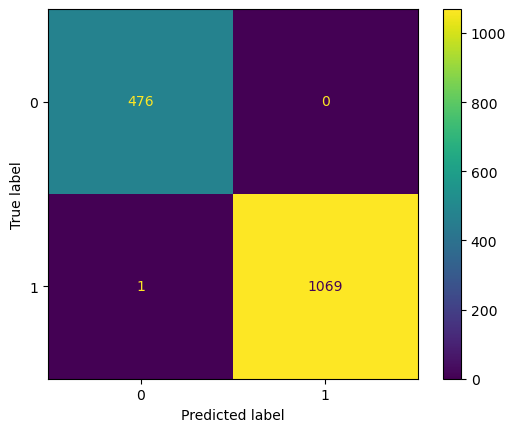

In [64]:
ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.show()

In [ ]:
dt_model2 = DecisionTreeClassifier(random_state=42)

dt_model2.fit(X2_train, y_train)

dt_pred2 = dt_model2.predict(X2_test)

print("Accuracy:", accuracy_score(y_test, dt_pred2))
print(classification_report(y_test, dt_pred2))

Accuracy: 0.9987063389391979
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       476
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      1546
   macro avg       1.00      1.00      1.00      1546
weighted avg       1.00      1.00      1.00      1546



In [70]:
dt_model3 = DecisionTreeClassifier(random_state=42)

dt_model3.fit(X3_train, y_train)

dt_pred3 = dt_model3.predict(X3_test)

print("Accuracy:", accuracy_score(y_test, dt_pred3))
print(classification_report(y_test, dt_pred3))

Accuracy: 0.9890038809831824
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       476
           1       1.00      0.99      0.99      1070

    accuracy                           0.99      1546
   macro avg       0.98      0.99      0.99      1546
weighted avg       0.99      0.99      0.99      1546



In [71]:
dt_model4 = DecisionTreeClassifier(random_state=42)

dt_model4.fit(X4_train, y_train)

dt_pred4 = dt_model4.predict(X4_test)

print("Accuracy:", accuracy_score(y_test, dt_pred4))
print(classification_report(y_test, dt_pred4))

Accuracy: 0.8635187580853816
              precision    recall  f1-score   support

           0       0.71      0.93      0.81       476
           1       0.97      0.83      0.89      1070

    accuracy                           0.86      1546
   macro avg       0.84      0.88      0.85      1546
weighted avg       0.89      0.86      0.87      1546



In [72]:
dt_acc = accuracy_score(y_test, dt_pred)
dt_acc2 = accuracy_score(y_test, dt_pred2)
dt_acc3 = accuracy_score(y_test, dt_pred3)
dt_acc4 = accuracy_score(y_test, dt_pred4)

In [75]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest1",
        "Random Forest2",
        "Random Forest3",
        "Random Forest4",

        "Decision Tree1",
        "Decision Tree2",
        "Decision Tree3",
        "Decision Tree4",

    ],

    "Dataset":[
        "X1","X2","X3","X4",
        "X1","X2","X3","X4",
    ],

    "Accuracy":[
        rf_acc1,rf_acc2,rf_acc3,rf_acc4,
        dt_acc,dt_acc2,dt_acc3,dt_acc4,
    ]

})

comparison

,Model,Dataset,Accuracy
0,Random Forest1,X1,0.998706
1,Random Forest2,X2,1.000000
2,Random Forest3,X3,0.989651
3,Random Forest4,X4,0.865459
4,Decision Tree1,X1,0.999353
5,Decision Tree2,X2,0.998706
6,Decision Tree3,X3,0.989004
7,Decision Tree4,X4,0.863519
